Part 1: Initial Setup and Image Formation

In [13]:
import cv2
import numpy as np
import imutils
from google.colab.patches import cv2_imshow
from google.colab import files

def get_perspective_warp(img, pts, ratio):
    """Calculates the transformation matrix and warps the image (Module 1)"""
    pts = pts.reshape(4, 2) * ratio
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0], rect[2] = pts[np.argmin(s)], pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1], rect[3] = pts[np.argmin(diff)], pts[np.argmax(diff)]

    (tl, tr, br, bl) = rect
    w = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
    h = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))

    dst = np.array([[0,0], [w-1,0], [w-1,h-1], [0,h-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(img, M, (w, h))

# File Upload Logic
print("Upload your document:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)
orig = image.copy()
ratio = image.shape[0] / 500.0
image = imutils.resize(image, height=500)

Upload your document:


Saving computer vision image.jpeg to computer vision image.jpeg


Part 2: Pre-processing & Edge Detection

In [14]:
# 1. Enhancement (Module 2)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.bilateralFilter(gray, 9, 75, 75) # Noise reduction while keeping edges

# 2. Morphological Closing (Module 2)
kernel = np.ones((5,5), np.uint8)
morphed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)

# 3. Edge Detection (Module 3)
edged = cv2.Canny(morphed, 75, 200)
edged = cv2.dilate(edged, None, iterations=1) # Ensure contour is solid

# 4. Find Contours
cnts = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]

screenCnt = None
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        screenCnt = approx
        break

Part 3:Segmentation & Final Enhancement

--- Final Scanned Output ---


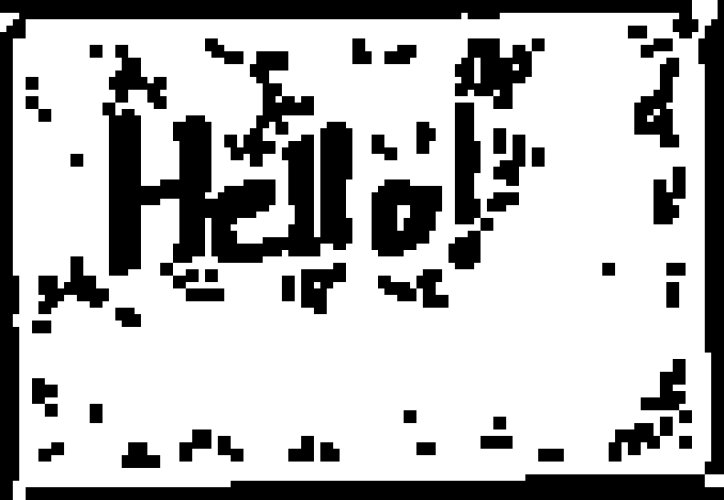

In [15]:
if screenCnt is not None:
    # 1. Perspective Warp (Module 1)
    warped = get_perspective_warp(orig, screenCnt, ratio)
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    # 2. Adaptive Thresholding (Module 4/Segmentation logic)
    # Using Gaussian adaptive threshold for better text extraction
    thresh = cv2.adaptiveThreshold(warped_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # 3. Final Cleanup (Module 2)
    # Erode to sharpen text, then resize for display
    kernel_small = np.ones((2, 2), np.uint8)
    final_scan = cv2.erode(thresh, kernel_small, iterations=1)

    print("--- Final Scanned Output ---")
    cv2_imshow(imutils.resize(final_scan, height=500))
else:
    print("Error: Could not find document outline.")

Part 4: Classification & Analysis


Detection Summary: ID/Business Card


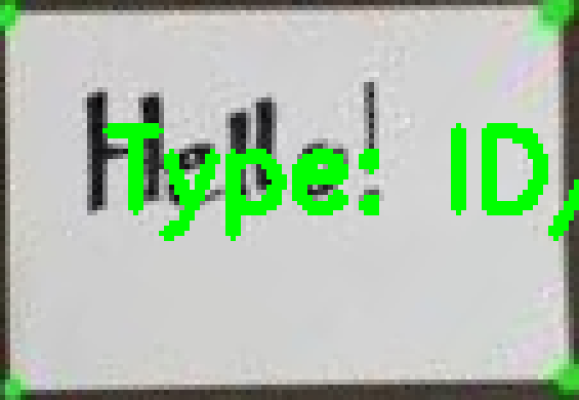

In [16]:
if screenCnt is not None:
    # 1. Aspect Ratio Classification
    h, w = warped.shape[:2]
    ar = w / float(h)

    if 0.6 < ar < 0.8: doc_type = "A4 Page"
    elif 1.2 < ar < 1.6: doc_type = "ID/Business Card"
    elif ar < 0.4: doc_type = "Receipt"
    else: doc_type = "Generic Document"

    # 2. Quality Score (Histogram Standard Deviation)
    std_dev = np.std(final_scan)
    status = "SUCCESS" if std_dev > 100 else "POOR QUALITY"
    color = (0, 255, 0) if status == "SUCCESS" else (0, 0, 255)

    # 3. Final Result Overlay
    result_img = warped.copy()
    cv2.putText(result_img, f"Type: {doc_type} | {status}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    print(f"\nDetection Summary: {doc_type}")
    cv2_imshow(imutils.resize(result_img, height=400))